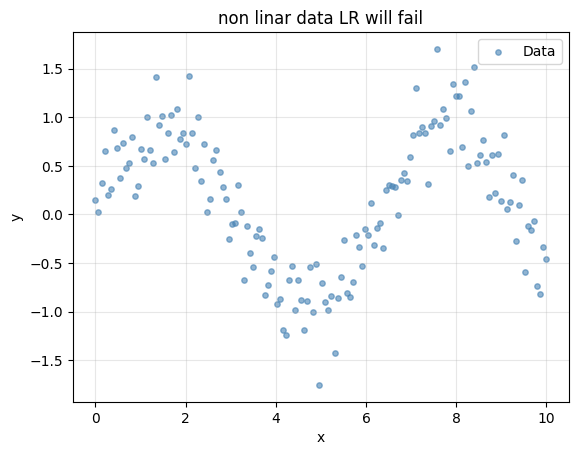

In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X=np.linspace(0,10,150)
Y=np.sin(X)+0.3*np.random.randn(150)

plt.scatter(X,Y,s=15,color='steelblue',alpha=0.6,label='Data')
plt.title("non linar data LR will fail")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

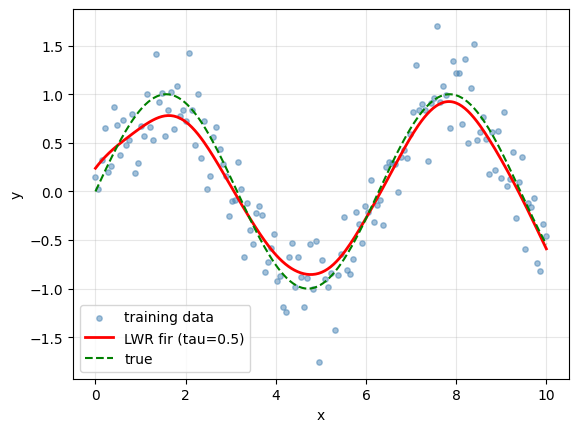

In [15]:
def lwr(x,X,Y,tau=0.5):
    m=len(X)
    weights=np.exp(-(x-X)**2/(2*tau**2))
    X_b = np.c_[np.ones(m), X]

    W=np.diag(weights)

    XTWX=X_b.T@W@X_b
    XTWY=X_b.T@W@Y

    theta=np.linalg.inv(XTWX)@XTWY

    return (np.array([1,x])@theta)

X_input=np.linspace(0,10,300)
#y_lwr=np.array([
   # lwr(x,X,Y)
   # for x in X_input
                #])
y_lwr=[]
for x in X_input:
    y_lwr.append(lwr(x,X,Y))

plt.scatter(X,Y,s=15,color='steelblue',alpha=0.5,label='training data')
plt.plot(X_input,y_lwr,color='red',lw=2,label='LWR fir (tau=0.5)')
plt.plot(X_input,np.sin(X_input),color='green',lw=1.5,linestyle='--',label='true')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


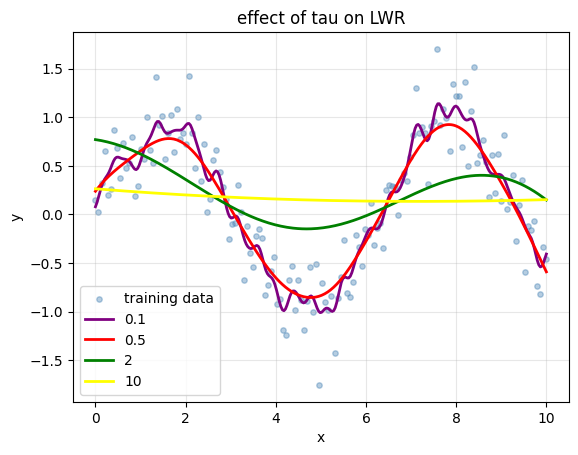

In [16]:
taus=[0.1,0.5,2,10]
colors=['purple','red','green','yellow']

plt.scatter(X,Y,s=15,color='steelblue',alpha=0.4,label='training data')
for i in range(len(taus)):
    y_pred=[]
    for x in X_input:
        y_pred.append(lwr(x,X,Y,taus[i]))
    plt.plot(X_input,y_pred,color=colors[i],lw=2,label=taus[i])

plt.title("effect of tau on LWR")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


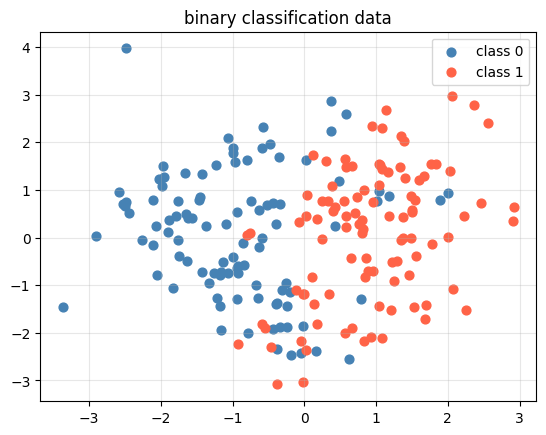

X train shape:  (160, 2)
Y train shape:  (160,)


In [22]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

X,Y= make_classification(n_samples=200,n_features=2,n_redundant=0,n_informative=2,random_state=42)

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

plt.scatter(X[Y==0][:,0],X[Y==0][:,1],color='steelblue',label='class 0',s=40)
plt.scatter(X[Y==1][:,0],X[Y==1][:,1],color='tomato',label='class 1',s=40)
plt.legend()
plt.title("binary classification data")
plt.grid(alpha=0.3)
plt.show()

print("X train shape: ",X_train.shape)
print("Y train shape: ",Y_train.shape)

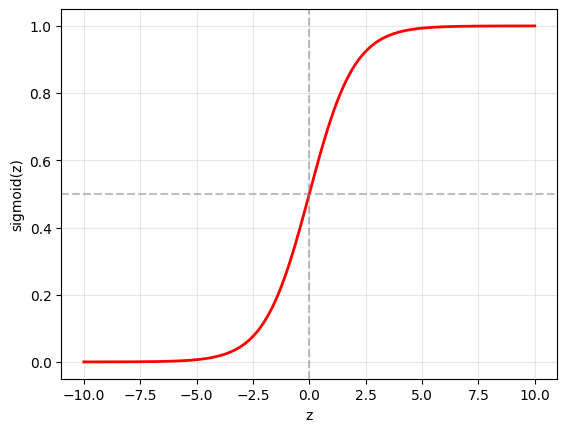

0.5
1.0
3.7200759760208356e-44


In [25]:
def sigmoid(z):
    return(1/(1+np.exp(-z)))

z=np.linspace(-10,10,300)
plt.plot(z,sigmoid(z),color='red',lw=2)
plt.axhline(0.5,color='gray',linestyle='--',alpha=0.5)
plt.axvline(0,color='gray',linestyle='--',alpha=0.5)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(alpha=0.3)
plt.show()

print(sigmoid(0))
print(sigmoid(100))
print(sigmoid(-100))

learned theta:  [-0.12760065  2.21817068 -0.22063442]


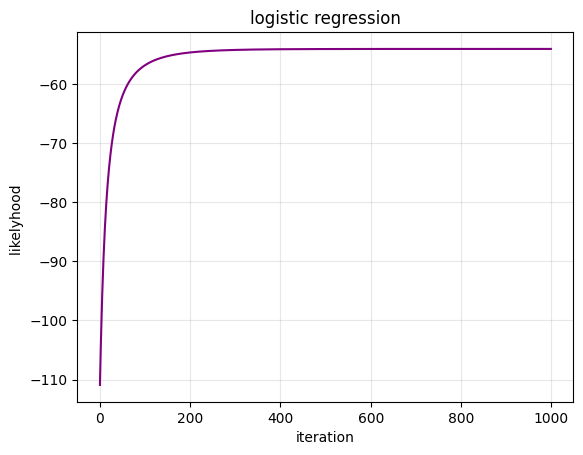

In [46]:
def logistic_regression(X,Y,learning_Rate=0.1,n_iterations=1000):
    m,n=X.shape
    X_b=np.c_[np.ones(m),X]

    theta=np.zeros(n+1)
    likelyhood_Array=[]

    for i in range(n_iterations):
        z=X_b@theta
        y_pred=sigmoid(z)

        eror=y_pred-Y
        likeyhood=np.sum(Y*np.log(y_pred)+(1-Y)*np.log(1-y_pred))
        likelyhood_Array.append(likeyhood)

        gradient=1/m*X_b.T@eror
        theta-=learning_Rate*gradient
    return theta,likelyhood_Array
theta,likelyhood_array=logistic_regression(X_train,Y_train)
print("learned theta: ",theta)

plt.plot(likelyhood_array,color='purple')
plt.xlabel("iteration")
plt.ylabel("likelyhood ")
plt.title("logistic regression")
plt.grid(alpha=0.3)
plt.show()

theta:  [-0.12861652  2.22259063 -0.2215235 ]


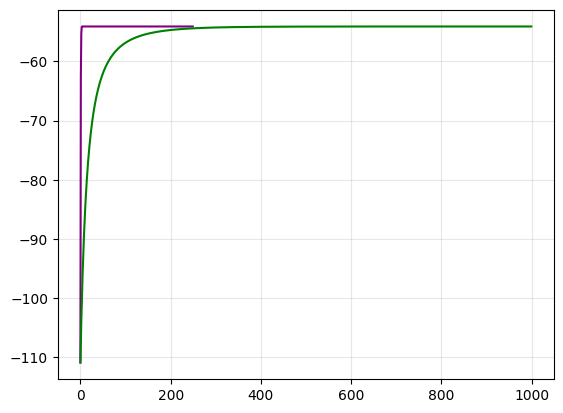

In [59]:
def logistic_Regression_newton(X,Y,n_iterations=250):
    m,n=X.shape
    X_b=np.c_[np.ones(m),X]

    theta=np.zeros(n+1)
    likelyhood_Array=[]

    for i in range(n_iterations):
        z=X_b@theta
        y_pred=sigmoid(z)

        error=y_pred-Y
        likeyhood=np.sum(Y*np.log(y_pred)+(1-Y)*np.log(1-y_pred))
        likelyhood_Array.append(likeyhood)

        gradient=1/m*X_b.T@error

        w_values=y_pred*(1-y_pred)
        W=np.diag(w_values)
        H=1/m*X_b.T@(W@X_b)

        theta-=np.linalg.inv(H)@gradient
    return theta,likelyhood_Array
theta_newton,likelyhood_newton=logistic_Regression_newton(X_train,Y_train)
print("theta: ", theta_newton)

plt.plot(likelyhood_newton,color='purple')
plt.plot(likelyhood_array,color='green')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def predic(X,theta,threshold=0.5):
    m,n=X.shape
    X_b=np.c_[np.ones(m),X]
    probabilites=sigmoid(X_b@theta)
    return(probabilites>=threshold).astype(int)

y_pred_gd=predic(X_test,theta)
y_pred_newton=predic(X_test,theta_newton)

from sklearn.linear_model import LogisticRegression
sk_model=LogisticRegression()
sk_model.fit(X_train,Y_train)
y_pred_sk=sk_model.predict(X_test)

print("Gradient Descent accuracy:", accuracy_score(Y_test, y_pred_gd))
print("Newton's Method accuracy: ", accuracy_score(Y_test, y_pred_newton))
print("Sklearn accuracy:         ", accuracy_score(Y_test, y_pred_sk))



Gradient Descent accuracy: 0.8
Newton's Method accuracy:  0.8
Sklearn accuracy:          0.8
